Устройство: cuda
Найдено фото: 17803
Обучающая эпоха 1/100 | Loss: 379.6 | Время: 295.2с | Beta: 0.05
Тестовая эпоха 1/100 | Loss:  573.8480 | Время: 5.5с
Обучающая эпоха 2/100 | Loss: 236.9 | Время: 51.8с | Beta: 0.10
Тестовая эпоха 2/100 | Loss:  482.8319 | Время: 5.4с
Обучающая эпоха 3/100 | Loss: 218.8 | Время: 51.5с | Beta: 0.15
Тестовая эпоха 3/100 | Loss:  408.5468 | Время: 5.4с
Обучающая эпоха 4/100 | Loss: 214.7 | Время: 51.2с | Beta: 0.20
Тестовая эпоха 4/100 | Loss:  375.2827 | Время: 5.6с
Обучающая эпоха 5/100 | Loss: 212.3 | Время: 51.7с | Beta: 0.25
Тестовая эпоха 5/100 | Loss:  336.4775 | Время: 5.7с
Обучающая эпоха 6/100 | Loss: 212.5 | Время: 51.2с | Beta: 0.30
Тестовая эпоха 6/100 | Loss:  323.2915 | Время: 5.7с
Обучающая эпоха 7/100 | Loss: 213.1 | Время: 51.3с | Beta: 0.35
Тестовая эпоха 7/100 | Loss:  305.7687 | Время: 5.6с
Обучающая эпоха 8/100 | Loss: 215.6 | Время: 51.2с | Beta: 0.40
Тестовая эпоха 8/100 | Loss:  304.9937 | Время: 5.5с
Обучающая эпоха 9/100 | Lo

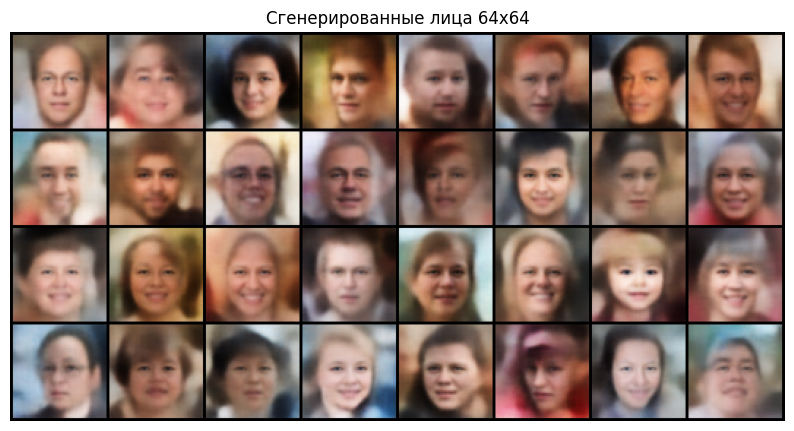

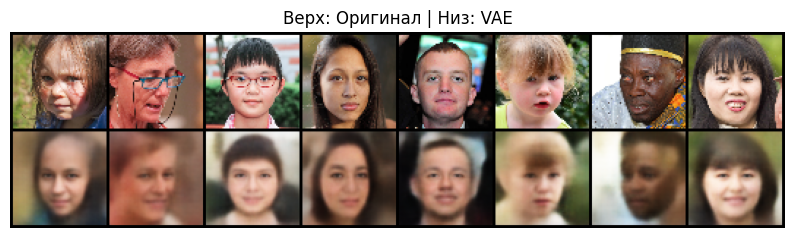

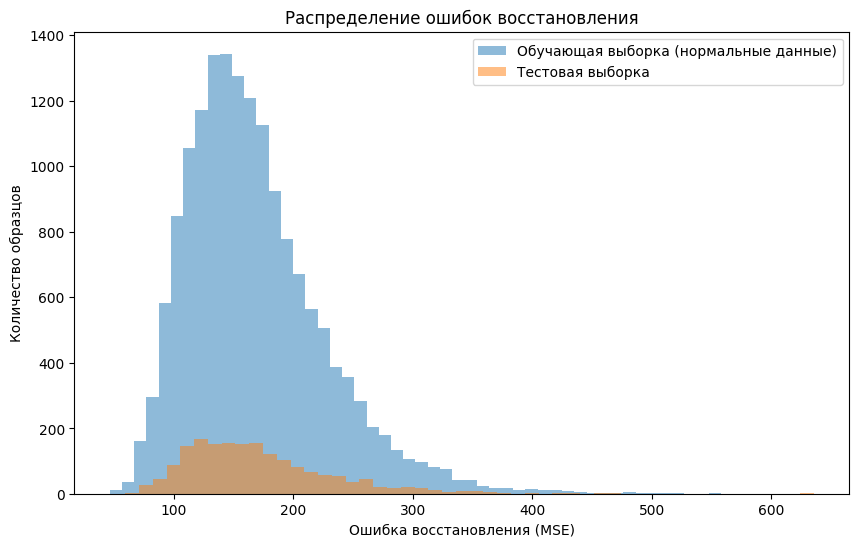

Порог для обнаружения аномалий (95-й процентиль): 276.70635986328125
Количество аномалий в тестовой выборке: 107


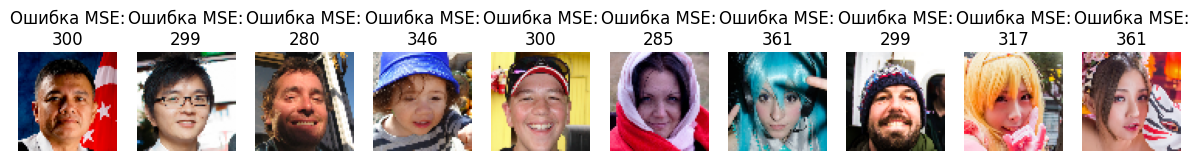

Общее время выполнения скрипта: 6022.65 секунд


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import torchvision # Убедитесь, что этот импорт присутствует
import numpy as np
import time # Импортируем модуль time для измерения времени
import os

# Определение устройства (GPU если доступно, иначе CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")

# Параметры модели
batch_size = 128
latent_dim = 256  # Размер латентного пространства
epochs = 100
learning_rate = 1e-3
image_size = 64

train_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

if not os.path.exists('/content/drive/MyDrive/dataset/'):
    print("Ошибка: Нет папки /content/drive/MyDrive/dataset/")
    exit()

# Загрузка
full_dataset = datasets.ImageFolder(root='/content/drive/MyDrive/dataset/', transform=train_transform)
print(f"Найдено фото: {len(full_dataset)}")

train_size = int(0.9 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)


# Определение архитектуры VAE
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Энкодер
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # -> 32 x 32 x 32
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1),  # -> 64 x 16 x 16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),  # -> 128 x 8 x 8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),  # -> 256 x 4 x 4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Flatten()
        )

        self.flatten_size = 256 * 4 * 4

        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)

        # Декодер
        self.decoder_input = nn.Linear(latent_dim, self.flatten_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # -> 128 x 8 x 8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # -> 64 x 16 x 16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # -> 32 x 32 x 32
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),  # -> 3 x 64 x 64
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)   # Стандартное отклонение
        eps = torch.randn_like(std)     # Случайная нормальная шумовая переменная
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, 256, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


# Функция потерь для VAE
def loss_function(recon_x, x, mu, logvar, beta):
    MSE = F.mse_loss(recon_x, x, reduction='sum')

    # Kullback-Leibler дивергенция
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return MSE + beta * KLD

# Инициализация модели и оптимизатора
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Функция обучения
def train(epoch):
    model.train()
    train_loss = 0
    start = time.time()
    current_beta = min(1.0, epoch / 20.0)

    for data, _ in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = loss_function(recon, data, mu, logvar,current_beta)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    # Выводим инфо
    if epoch % 1 == 0:
        print(
            f"Обучающая эпоха {epoch}/{epochs} | Loss: {train_loss / len(train_loader.dataset):.1f} | Время: {time.time() - start:.1f}с | Beta: {current_beta:.2f}")

def test(epoch):
    model.eval()
    test_loss = 0
    start = time.time()
    beta = 1
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            recon, mu, logvar = model(data)
            test_loss += loss_function(recon, data, mu, logvar,beta).item()

    test_loss /= len(test_loader.dataset)
    # Выводим инфо
    if epoch % 1 == 0:
        print(
            f"Тестовая эпоха {epoch}/{epochs} | Loss:  {test_loss:.4f} | Время: {time.time() - start:.1f}с")

# Зафиксируем время начала всего скрипта
script_start_time = time.time()


# Обучение модели
for epoch in range(1, epochs + 1):
    train(epoch)
    test(epoch)

# Генерация новых изображений
with torch.no_grad():
    z = torch.randn(32, latent_dim).to(device)  # Генерируем 32 лица
    gen_imgs = model.decode(z).cpu()

    plt.figure(figsize=(10, 6))
    plt.axis("off")
    plt.title("Сгенерированные лица 64x64")
    plt.imshow(torchvision.utils.make_grid(gen_imgs, nrow=8).permute(1, 2, 0))
    plt.show()

# Восстановление изображений из тестового набора
with torch.no_grad():
    data, _ = next(iter(test_loader))
    data = data.to(device)[:8]
    recon, _, _ = model(data)
    comparison = torch.cat([data, recon])

    plt.figure(figsize=(10, 3))
    plt.axis("off")
    plt.title("Верх: Оригинал | Низ: VAE")
    plt.imshow(torchvision.utils.make_grid(comparison.cpu(), nrow=8).permute(1, 2, 0))
    plt.show()


# Функция для вычисления ошибок восстановления
def compute_reconstruction_loss(loader):
    model.eval()
    losses = []
    labels = []
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            recon, mu, logvar = model(data)

            loss = F.mse_loss(recon, data, reduction='none')
            loss = loss.view(loss.size(0), -1).sum(dim=1)

            losses.append(loss.cpu().numpy())
            labels.append(target.numpy())

    # Объединяем массивы потерь и меток
    losses = np.concatenate(losses)
    labels = np.concatenate(labels)
    return losses, labels

# Вычисление ошибок восстановления для обучающей и тестовой выборок
train_losses, _ = compute_reconstruction_loss(train_loader)
test_losses, test_labels = compute_reconstruction_loss(test_loader)

# Визуализация распределения ошибок восстановления
plt.figure(figsize=(10,6))
plt.hist(train_losses, bins=50, alpha=0.5, label='Обучающая выборка (нормальные данные)')
plt.hist(test_losses, bins=50, alpha=0.5, label='Тестовая выборка')
plt.legend(loc='upper right')
plt.title("Распределение ошибок восстановления")
plt.xlabel("Ошибка восстановления (MSE)")
plt.ylabel("Количество образцов")
plt.show()

# Установка порога для обнаружения аномалий
# Например, установим порог как 95-й процентиль ошибок восстановления обучающей выборки
threshold = np.percentile(train_losses, 95)
print(f"Порог для обнаружения аномалий (95-й процентиль): {threshold}")

# Обнаружение аномалий в тестовой выборке
anomaly_indices = np.where(test_losses > threshold)[0]
print(f"Количество аномалий в тестовой выборке: {len(anomaly_indices)}")


# Отображение некоторых аномалий
def show_anomalies(indices, labels, num=10):
    num = min(num, len(indices))
    if num == 0:
        print("Аномалий не найдено для отображения.")
        return

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(indices[:num]):
        img = test_loader.dataset[idx][0].permute(1, 2, 0).numpy()
        label = labels[idx]

        plt.subplot(1, num, i + 1)
        plt.imshow(img)
        plt.title(f"Ошибка MSE:\n{test_losses[idx]:.0f}")
        plt.axis('off')
    plt.show()

# Вывод первых 10 аномалий
show_anomalies(anomaly_indices, test_labels, num=10)

# Зафиксируем время окончания всего скрипта
script_end_time = time.time()
script_duration = script_end_time - script_start_time
print(f"Общее время выполнения скрипта: {script_duration:.2f} секунд")